In [1]:
import torch # pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import cv2, os, shutil, glob, json
import numpy as np
import pandas as pd
import torch.nn as nn
import seaborn as sns
from utils.Files import *
pd.set_option('display.max_columns', None)

In [2]:
OPTIONS = json.loads(open('../Task/info.json', 'r').read())
OPTIONS

{'dataset': 'dataset1',
 'network': 'deep_lab',
 'encoder': 'resnet101',
 'weights': 'imagenet',
 'img_size': 640,
 'tile_size': 0,
 'n_aug': 3,
 'multiclass': True,
 'radius': 6,
 'lr': 0.0005,
 'loss': 'dice_focal',
 'batch_size': 2,
 'scheduler': 'plateau',
 'dropout': 0.1,
 'num_filters': 16}

In [3]:
df = pd.read_csv('Database/Target/landmarks.csv')
#df = df.head(50)
print(len(df))
df.head()

1000


,id,ext,1_x,1_y,2_x,2_y,3_x,3_y,4_x,4_y,5_x,5_y,6_x,6_y,7_x,7_y,8_x,8_y,9_x,9_y,10_x,10_y,11_x,11_y,12_x,12_y,13_x,13_y,14_x,14_y,15_x,15_y,16_x,16_y,17_x,17_y,18_x,18_y,19_x,19_y,20_x,20_y,21_x,21_y,22_x,22_y,23_x,23_y,24_x,24_y,25_x,25_y,26_x,26_y,27_x,27_y,28_x,28_y,29_x,29_y,path
0,cks2ip8fq29yq0yufc4scftj8,.png,1315,1086,1338,1048,1333,1564,1297,1733,1183,508,1112,790,1348,1663,793,1138,1585,946,523,1265,499,758,445,1061,449,980,1336,1707,593,1496,291,958,1189,1329,1371,1308,1147,1334,1177,1339,1288,1106,1400,1334,1119,1339,1288,1556,1501,1369,1508,1212,1240,557,1488,1608,1458,1067,img_1.png
1,cks2ip8fq29z00yufgnfla2tf,.png,1252,1090,1276,1008,1219,1516,1152,1742,1152,485,1036,847,1226,1647,759,1134,1523,888,480,1283,469,712,403,1067,420,1015,1208,1712,564,1468,247,989,1099,1336,1310,1326,1015,1331,1073,1339,1230,1140,1375,1303,986,1327,1182,1501,1455,1399,1471,1159,1203,510,1359,1606,1398,1047,img_2.png
2,cks2ip8fq29za0yuf0tqu1qjs,.jpg,1388,1072,1426,1027,1336,1478,1314,1702,1257,447,1172,811,1363,1607,881,1088,1694,915,529,1285,568,696,458,1069,484,980,1357,1673,595,1557,354,981,1167,1309,1401,1293,1090,1307,1221,1313,1341,1089,1435,1312,1039,1280,1269,1495,1514,1358,1545,1209,1329,480,1473,1621,1547,1039,img_3.png
3,cks2ip8fq2a0j0yufdfssbc09,.png,1313,1133,1335,1065,1301,1534,1263,1761,1165,556,1043,883,1325,1697,790,1217,1579,921,499,1352,479,888,407,1204,392,1064,1310,1746,581,1541,240,1027,1169,1390,1339,1321,1069,1394,1157,1381,1278,1160,1423,1375,1069,1380,1239,1578,1538,1437,1547,1239,1214,546,1430,1656,1486,1069,img_4.png
4,cks2ip8fq2a0t0yufgab484s9,.png,1347,1027,1387,989,1407,1361,1400,1590,1280,471,1196,770,1454,1514,881,1102,1688,881,544,1296,576,752,437,1102,418,957,1440,1566,665,1531,319,983,1238,1243,1393,1201,1161,1255,1216,1227,1313,1039,1422,1250,1154,1236,1356,1417,1580,1260,1566,1130,1332,489,1592,1484,1534,1029,img_5.png


In [4]:
df['path'] = [os.path.join('Database/Target/images/', name) for name in df.path]
df.head()

,id,ext,1_x,1_y,2_x,2_y,3_x,3_y,4_x,4_y,5_x,5_y,6_x,6_y,7_x,7_y,8_x,8_y,9_x,9_y,10_x,10_y,11_x,11_y,12_x,12_y,13_x,13_y,14_x,14_y,15_x,15_y,16_x,16_y,17_x,17_y,18_x,18_y,19_x,19_y,20_x,20_y,21_x,21_y,22_x,22_y,23_x,23_y,24_x,24_y,25_x,25_y,26_x,26_y,27_x,27_y,28_x,28_y,29_x,29_y,path
0,cks2ip8fq29yq0yufc4scftj8,.png,1315,1086,1338,1048,1333,1564,1297,1733,1183,508,1112,790,1348,1663,793,1138,1585,946,523,1265,499,758,445,1061,449,980,1336,1707,593,1496,291,958,1189,1329,1371,1308,1147,1334,1177,1339,1288,1106,1400,1334,1119,1339,1288,1556,1501,1369,1508,1212,1240,557,1488,1608,1458,1067,Database/Target/images/img_1.png
1,cks2ip8fq29z00yufgnfla2tf,.png,1252,1090,1276,1008,1219,1516,1152,1742,1152,485,1036,847,1226,1647,759,1134,1523,888,480,1283,469,712,403,1067,420,1015,1208,1712,564,1468,247,989,1099,1336,1310,1326,1015,1331,1073,1339,1230,1140,1375,1303,986,1327,1182,1501,1455,1399,1471,1159,1203,510,1359,1606,1398,1047,Database/Target/images/img_2.png
2,cks2ip8fq29za0yuf0tqu1qjs,.jpg,1388,1072,1426,1027,1336,1478,1314,1702,1257,447,1172,811,1363,1607,881,1088,1694,915,529,1285,568,696,458,1069,484,980,1357,1673,595,1557,354,981,1167,1309,1401,1293,1090,1307,1221,1313,1341,1089,1435,1312,1039,1280,1269,1495,1514,1358,1545,1209,1329,480,1473,1621,1547,1039,Database/Target/images/img_3.png
3,cks2ip8fq2a0j0yufdfssbc09,.png,1313,1133,1335,1065,1301,1534,1263,1761,1165,556,1043,883,1325,1697,790,1217,1579,921,499,1352,479,888,407,1204,392,1064,1310,1746,581,1541,240,1027,1169,1390,1339,1321,1069,1394,1157,1381,1278,1160,1423,1375,1069,1380,1239,1578,1538,1437,1547,1239,1214,546,1430,1656,1486,1069,Database/Target/images/img_4.png
4,cks2ip8fq2a0t0yufgab484s9,.png,1347,1027,1387,989,1407,1361,1400,1590,1280,471,1196,770,1454,1514,881,1102,1688,881,544,1296,576,752,437,1102,418,957,1440,1566,665,1531,319,983,1238,1243,1393,1201,1161,1255,1216,1227,1313,1039,1422,1250,1154,1236,1356,1417,1580,1260,1566,1130,1332,489,1592,1484,1534,1029,Database/Target/images/img_5.png


In [5]:
img  = cv2.imread(df.iloc[0].path, cv2.IMREAD_GRAYSCALE)
h, w = img.shape[:2]
print(f'image size:', (w, h))

n_images   = len(df) 
total_dots = len([col for col in df.columns if '_x' in col or '_y' in col])//2
total_dots

image size: (1968, 2225)


29

In [6]:
MULTICLASS    = OPTIONS.get('multiclass')
IMG_SIZE      = OPTIONS.get('img_size')
AUG_PER_IMAGE = OPTIONS.get('n_aug')
TILE_SIZE     = OPTIONS.get('tile_size')
RADIUS        = OPTIONS.get('radius')

MULTICLASS, IMG_SIZE, AUG_PER_IMAGE, TILE_SIZE, RADIUS

(True, 640, 3, 0, 6)

# TAMANHO DE IMAGEM

In [7]:
if IMG_SIZE is None:
    IMG_SIZE = min(cv2.imread(df.iloc[0].path, cv2.IMREAD_GRAYSCALE).shape)

IMG_SIZE

640

Text(0, 0.5, 'img_size')

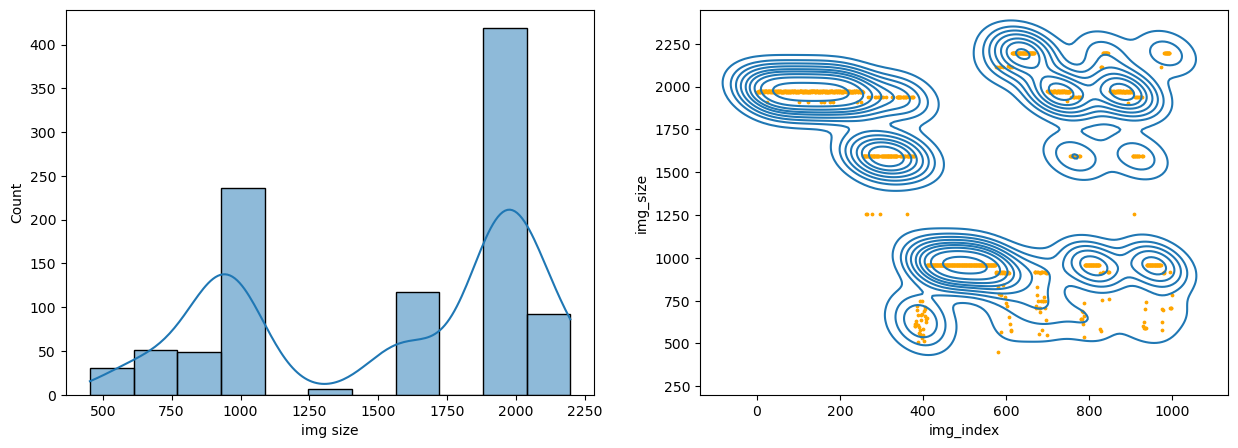

In [8]:
def getSize(path):
    return min(cv2.imread(path, cv2.IMREAD_GRAYSCALE).shape)

df['img_size'] = df.path.apply(getSize)
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.histplot(df.img_size, kde=True)
plt.xlabel('img size')

plt.subplot(1, 2, 2)
sns.kdeplot(x=df.index, y=df.img_size, bw_adjust=0.5)
plt.scatter(df.index,   df.img_size, color='orange', s=3)
plt.xlabel('img_index'); plt.ylabel('img_size')

In [9]:
REMOVE_LOW = False

if REMOVE_LOW:
    df = df.loc[df.img_size > 1800]
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(df.img_size, kde=True)
    plt.xlabel('img size')

    plt.subplot(1, 2, 2)
    sns.kdeplot(x=df.index, y=df.img_size, bw_adjust=0.5)
    plt.scatter(df.index,   df.img_size, color='orange', s=3)
    plt.xlabel('img_index'); plt.ylabel('img_size'); plt.show()

# PROCESSAMENTO DAS IMAGENS

(640, 640)

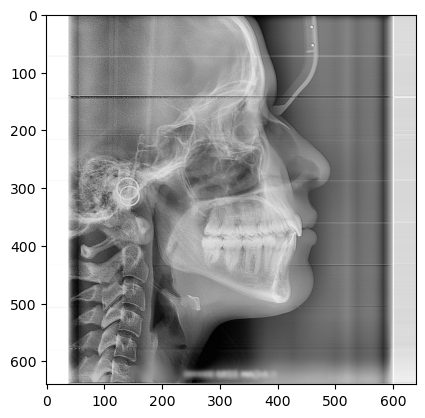

In [10]:
def clahe(img):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(img)

def sharpen(img):
    blur = cv2.GaussianBlur(img, (0,0), 3)
    return cv2.addWeighted(img, 1.5, blur, -0.5, 0)

def resize(img, size=640):
    new_h, new_w, top, bottom, left, right, scale = letterbox(img, size)
    img_res = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)
    return cv2.copyMakeBorder(img_res, top, bottom, left, right, cv2.BORDER_REPLICATE, value=0)

def processImage(index, options):
    img = cv2.imread(df.iloc[index].path, cv2.IMREAD_GRAYSCALE)
    
    if options.get('clahe'):
        img = clahe(img)
    
    if options.get('sharpen'): 
        img = sharpen(img)
    
    img = resize(img, IMG_SIZE)
    return img


options = {'clahe': True, 'sharpen': True}
img     = processImage(0, options)
plt.imshow(img, cmap='gray')
img.shape

# PROCESSANDO MÁSCARAS

(640, 640)

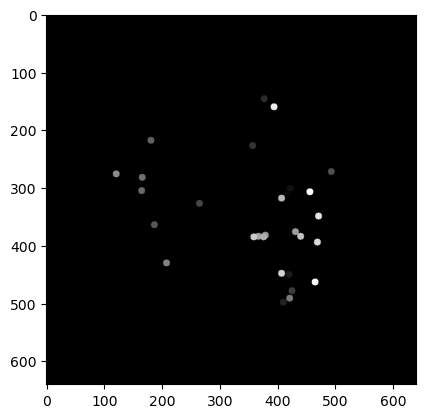

In [11]:
def processMask(index):
    row = df.iloc[index]
    img = cv2.imread(row.path, cv2.IMREAD_GRAYSCALE)

    h, w, top, bottom, left, right, scale = letterbox(img, IMG_SIZE)
    mask = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)

    for dot in range(1, total_dots+1):
        x = int(row[f'{dot}_x'])
        y = int(row[f'{dot}_y'])
        
        x = int(round(x*scale + left))
        y = int(round(y*scale + top)) 
        color = dot if MULTICLASS else 1
        cv2.circle(img=mask, center=(x, y), radius=RADIUS, color=color, thickness=-1)

    return mask.astype(np.uint8)


mask = processMask(0)
plt.imshow(mask, cmap='gray', vmin=0, vmax=mask.max())
mask.shape

# PROCESSAMENTO GERAL

valor máximo:  255


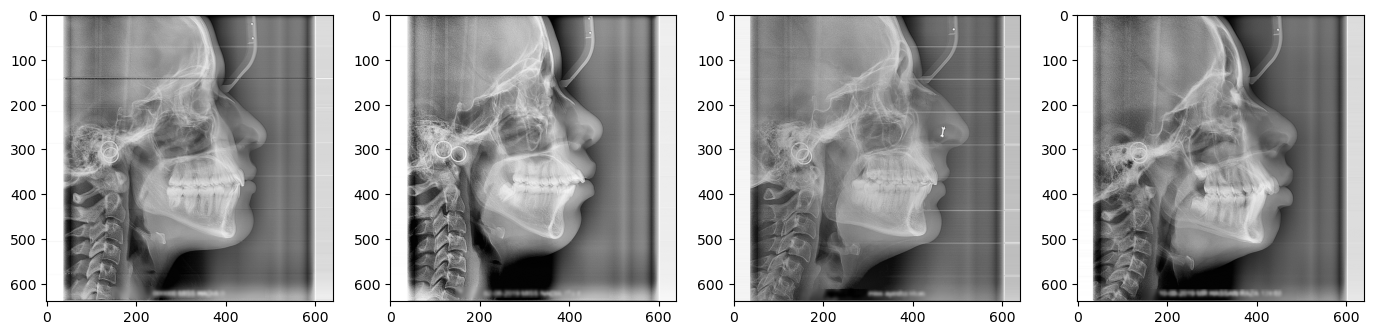

In [12]:
images = np.array([processImage(i, options) for i in range(len(df))])
print('valor máximo: ', np.max(images))

plt.figure(figsize=(17, 17))
plt.subplot(1, 4, 1)
plt.imshow(images[0], cmap='gray')

plt.subplot(1, 4, 2)
plt.imshow(images[1], cmap='gray')

plt.subplot(1, 4, 3)
plt.imshow(images[2], cmap='gray')

plt.subplot(1, 4, 4)
plt.imshow(images[3], cmap='gray')

unique mask values: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29]


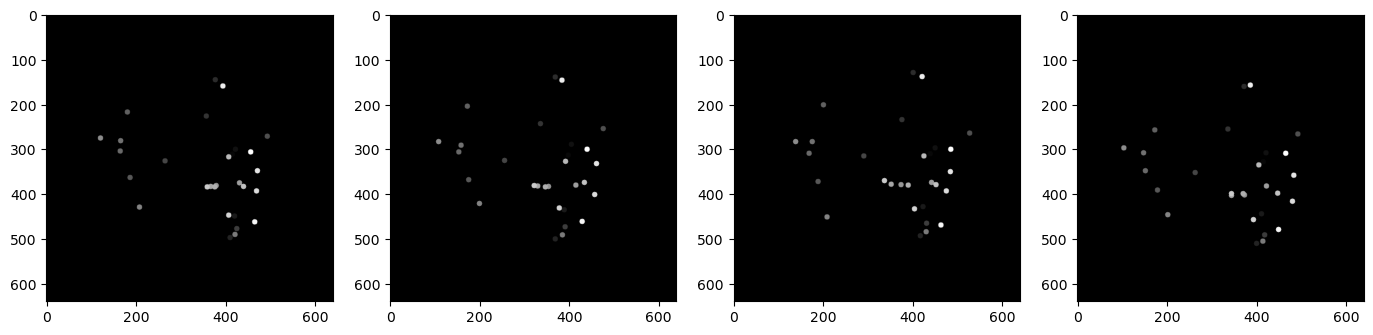

In [13]:
masks  = np.array([processMask(i) for i in range(len(df))])
unique = np.unique(masks)

print('unique mask values:', unique)
plt.figure(figsize=(17, 17))

plt.subplot(1, 4, 1)
plt.imshow(masks[0], cmap='gray', vmin=0, vmax=unique.max())

plt.subplot(1, 4, 2)
plt.imshow(masks[1], cmap='gray', vmin=0, vmax=unique.max())

plt.subplot(1, 4, 3)
plt.imshow(masks[2], cmap='gray', vmin=0, vmax=unique.max())

plt.subplot(1, 4, 4)
plt.imshow(masks[3], cmap='gray', vmin=0, vmax=unique.max())

# VERIFICAÇÃO DE INTEGRIDADE

In [14]:
n_images  = len(images)
n_classes = len(np.unique(masks[0]))

assert (len(images) == len(masks))
n_images, n_classes

(1000, 30)

In [15]:
np.unique(masks[:30])

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29], dtype=uint8)

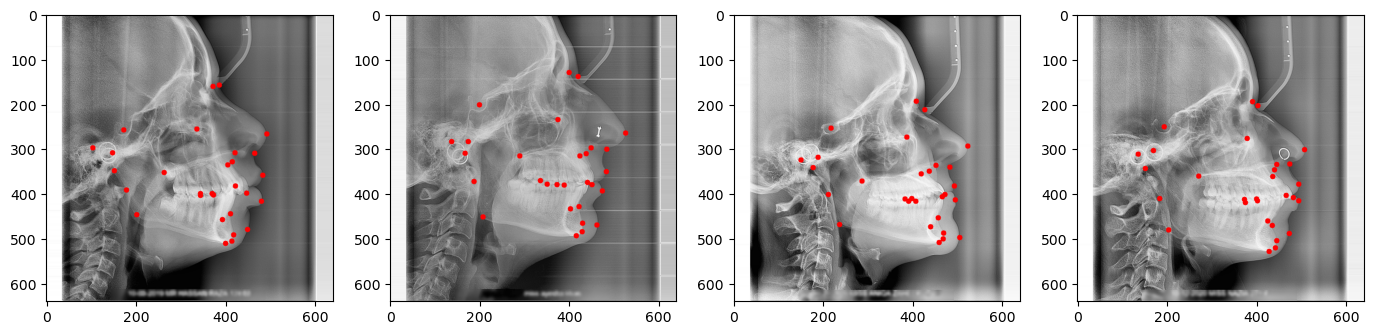

In [16]:
def plotSamples():
    paste = lambda index: pasteMask(processImage(index, options), processMask(index))

    plt.figure(figsize=(17, 17))
    plt.subplot(1, 4, 1)
    plt.imshow(paste(3), cmap='gray', vmin=0, vmax=1)

    plt.subplot(1, 4, 2)
    plt.imshow(paste(2), cmap='gray', vmin=0, vmax=1)

    plt.subplot(1, 4, 3)
    plt.imshow(paste(5), cmap='gray', vmin=0, vmax=1)

    plt.subplot(1, 4, 4)
    plt.imshow(paste(7), cmap='gray', vmin=0, vmax=1)
    plt.show()


plotSamples()

In [17]:
pasteMask(images[30], masks[30])

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [233, 233, 233],
        [233, 233, 233],
        [233, 233, 233]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [232, 232, 232],
        [232, 232, 232],
        [232, 232, 232]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [233, 233, 233],
        [233, 233, 233],
        [233, 233, 233]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [247, 247, 247],
        [247, 247, 247],
        [247, 247, 247]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [248, 248, 248],
        [248, 248, 248],
        [248, 248, 248]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [253, 253, 253],
        [253, 253, 253],
        [253, 253, 253]]

# SPLITS DOS DADOS

In [18]:
VAL_SIZE  = 0.10
TEST_SIZE = 0.10
VAL_SIZE  = VAL_SIZE / (1 - TEST_SIZE)

In [19]:
xTemp, xTest, yTemp, yTest = train_test_split(images, masks, test_size=TEST_SIZE, random_state=42)
del images, masks
xTrain, xVal, yTrain, yVal = train_test_split(xTemp, yTemp, test_size=VAL_SIZE, random_state=42)
del xTemp, yTemp

print(f'train: {len(yTrain)} files')
print(f'val:   {len(yVal)} files')
print(f'test:  {len(yTest)} files')

train: 800 files
val:   100 files
test:  100 files


# AUMENTO DE DADOS

In [20]:
import albumentations as A

/home/grva/anaconda3/envs/torch-gpu/lib/python3.13/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_1557992/3681240407.py:16: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=32, max_width=32, p=0.5), # Força aprendizado contextual


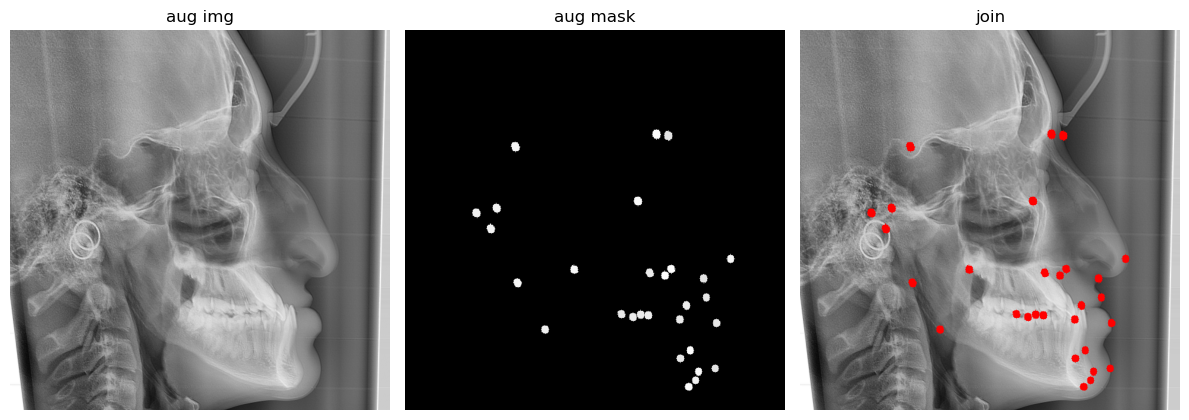

In [21]:
"""
A.Affine(
    scale=(0.95, 1.05),
    rotate=(-12, 12),
    translate_percent=(-0.05, 0.05),
    shear=(-2, 2),
    border_mode=cv2.BORDER_REFLECT_101, 
    p=1.0
)
"""

class Augmentations:
    options = [
        A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=15, p=0.8), # Mais agressivo
        A.Perspective(p=0.5),
        A.CoarseDropout(max_holes=8, max_height=32, max_width=32, p=0.5), # Força aprendizado contextual
        
        A.OneOf([
            A.GaussianBlur(blur_limit=(3, 3), p=0.2), 
            A.RandomGamma(gamma_limit=(80, 120), p=0.3)], 
        p=0.5),

        A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.3)
    ]

    def __init__(self):
        self.seed = 32

    def get(self, img, mask, seed=None):
        transform = A.Compose(self.options, additional_targets={'mask': 'mask'}, seed=seed)
        data = transform(image=img, mask=mask, seed=seed)
        return data['image'], np.round(data['mask']).astype(np.uint8)
    
    def compute(self, img, mask, n_aug):
        images = []
        masks  = []

        for n in range(n_aug):
            aug_img, aug_mask = self.get(img, mask, seed=self.seed)
            self.seed = (self.seed + 10)

            images.append(aug_img)
            masks.append(aug_mask)

        return (images, masks)


aug = Augmentations()
img, mask = aug.get(xTrain[0].copy(), yTrain[0].copy())
jun       = pasteMask(img, mask)
compare({'aug img': img, 'aug mask': mask*255, 'join': jun}, figsize=(12, 9))

# TILES

In [22]:
class Tiles:
    def __init__(self, size):
        self.size = size
    
    def getStart(self, dimsize):
        distance = (dimsize - self.size)
        starts   = list(range(0, distance+1, self.size))

        if dimsize <= self.size:
            return [0] 
        
        if starts[-1] != distance: 
            starts.append(dimsize - self.size)
        
        return starts    

    def getCrops(self, img):
        y_starts = self.getStart(img.shape[0])
        x_starts = self.getStart(img.shape[1])
        tiles = []

        for y in y_starts:
            for x in x_starts:
                endX = x + self.size
                endY = y + self.size
                tiles.append(img[y:endY, x:endX])

        return tiles
    
    def get(self, img, mask):
        images = self.getCrops(img)
        masks  = self.getCrops(mask)
        return images, masks


tiles = Tiles(TILE_SIZE)

if TILE_SIZE > 0:
    x, y  = tiles.get(xTrain[0], yTrain[0])
    compare({'tile img': x[3], 'tile mask': y[3]*255}, figsize=(7, 4))

# SALVANDO DADOS

In [23]:
class Saver:
    def __init__(self, target='Processed'):
        self.DIR   = os.path.join(f'Database', target)
        self.index = 0
        
        for split in ['train', 'val', 'test']:
            setFolder(f'{self.DIR}/{split}/images')
            setFolder(f'{self.DIR}/{split}/masks')

    def to(self, split, img, mask):
        path = os.path.join(self.DIR, split)
        self.index = (self.index + 1)
        
        if TILE_SIZE == 0:
            np.save(f'{path}/images/img_{self.index}.npy', img)
            np.save(f'{path}/masks/img_{self.index}.npy', mask)
            return
        
        imgs, masks = tiles.get(img, mask)
        for t, (img, mask) in enumerate(zip(imgs, masks)):
            np.save(f'{path}/images/img_{self.index}_tile_{t+1}.npy', img)
            np.save(f'{path}/masks/img_{self.index}_tile_{t+1}.npy', mask)

    def dataset(self, split, images, masks):
        for img, mask in zip(images, masks):
            self.to(split, img, mask)

            if AUG_PER_IMAGE > 0 and split == 'train':
                xData, yData = aug.compute(img, mask, AUG_PER_IMAGE)
                
                for img, mask in zip(xData, yData):
                    self.to(split, img, mask)

        total = os.listdir(f"{self.DIR}/{split}/images").__len__()
        print(f'{split}: {total} images')


saver = Saver('Processed')
saver.dataset('train', xTrain, yTrain)
saver.dataset('val',   xVal,   yVal)
saver.dataset('test',  xTest,  yTest)
del xTrain, yTrain, xVal, yVal, xTest, yTest

train: 3200 images
val: 100 images
test: 100 images


In [24]:
with open(f'Database/info.json', 'w', encoding='utf-8') as file:
   json.dump(OPTIONS, file, ensure_ascii=False, indent=4)

# VISUALIZAÇÃO

In [25]:
OPTIONS.update({'n_images': n_images, 'n_classes': n_classes})

showing img 0


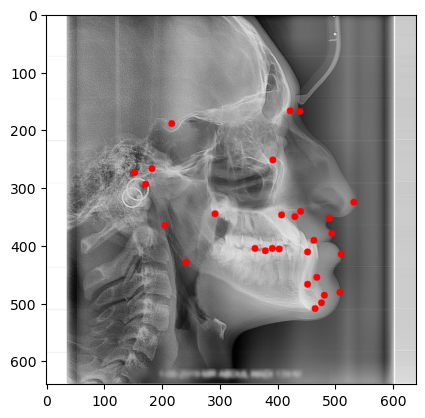

showing img 1


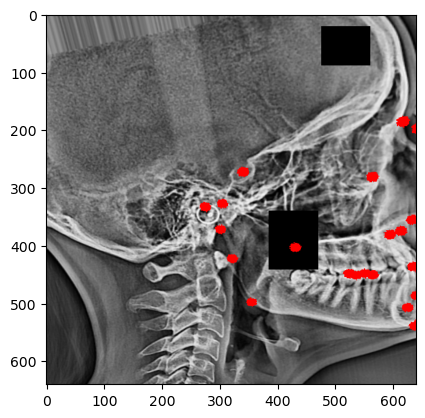

showing img 2


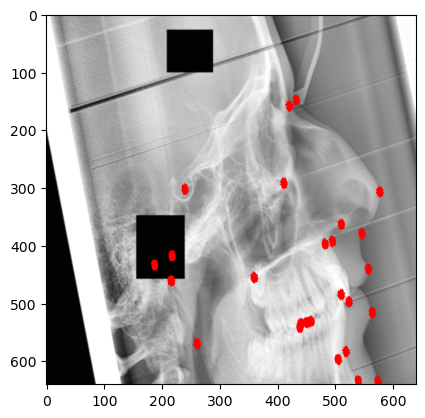

showing img 3


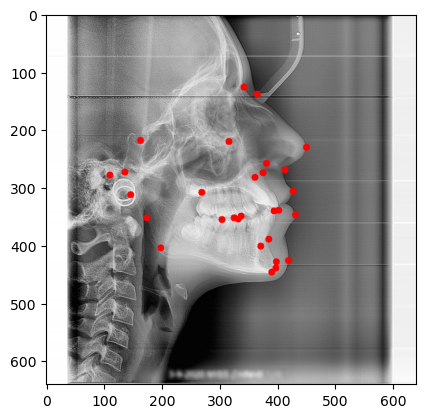

showing img 4


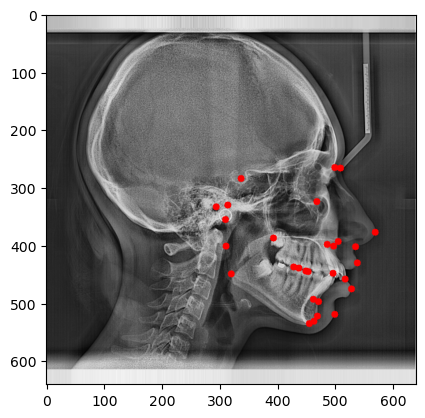

In [26]:
for i in range(5):
    img = np.load(getFile('Database/Processed/train/images', i))
    msk = np.load(getFile('Database/Processed/train/masks',  i))
    
    print('showing img', i)
    plt.imshow(pasteMask(img, msk), cmap='gray')
    plt.show()